# Mô hình dựa trên mệnh đề + SkinCAP — huấn luyện và đánh giá trên Google Colab

Notebook này là workflow Colab cho biến thể mệnh đề (`main_proposition.py`) trên SkinCAP-47. Nó tạo một lần chạy mới hoặc tiếp tục một run đang dở từ `checkpoints/latest.pt`, sau đó đánh giá `best.pt` và xuất artefact giải thích.

1. Clone nhánh có code mệnh đề và cài dependency.
2. Kiểm tra GPU, Drive, ClinicalBERT, dữ liệu và knowledge base.
3. Tạo hoặc chọn thư mục chạy, rồi ghi cấu hình 20 epoch.
4. Huấn luyện/tiếp tục `main_proposition.py`.
5. Kiểm tra checkpoint và metric đã lưu.
6. Tùy chọn: so sánh với một run RAD gốc và xem giải thích định tính.

**Trước khi chạy:** chọn **Runtime → Change runtime type → GPU**.

> Mỗi thí nghiệm mới được đặt trong `Proposition-outputs/skin-proposition-20ep/YYYYMMDD_HHMMSS`. Để resume, giữ nguyên cả `EXPERIMENT_NAME` và `RUN_ID`. Hai notebook chỉ có cùng cấu hình tối ưu hóa; chúng là hai mô hình khác nhau, nên không khẳng định các kết quả sẽ hoàn toàn tương đương.

## 1. Chuẩn bị Python và repository

Clone **nhánh `RAD-colab-enhanced`** (nhánh `main` chỉ có RAD gốc, không có code mệnh đề). Nếu repository đã có trong phiên Colab hiện tại, ô này chuyển sang đúng nhánh và kéo commit mới nhất.


In [ ]:
import subprocess
import sys
from pathlib import Path

print("Python:", sys.version)

REPO_DIR = Path("/content/RAD-colab")
REPO_URL = "https://github.com/trisle0805/RAD-colab.git"
BRANCH = "RAD-colab-enhanced"

if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "--branch", BRANCH, REPO_URL, str(REPO_DIR)],
        check=True,
    )
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", BRANCH], check=True)

subprocess.run(["git", "-C", str(REPO_DIR), "log", "--oneline", "-3"], check=True)
assert (REPO_DIR / "main_proposition.py").is_file(), "Sai nhánh: không thấy main_proposition.py"

# Tương thích cả layout mới lẫn commit Colab cũ chưa chuyển file vào requirements/.
COLAB_REQUIREMENTS = next(
    (path for path in (
        REPO_DIR / "requirements/colab-skin.txt",
        REPO_DIR / "requirements-colab-skin.txt",
    ) if path.is_file()),
    None,
)
assert COLAB_REQUIREMENTS is not None, "Không tìm thấy file dependency Colab cho SkinCAP."
print(f"✅ Repository: {REPO_DIR} (nhánh {BRANCH})")
print("Requirements:", COLAB_REQUIREMENTS.relative_to(REPO_DIR))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Cloning into '/content/RAD-colab'...
remote: Enumerating objects: 505, done.
remote: Counting objects: 100% (505/505), done.
remote: Compressing objects: 100% (320/320), done.
remote: Total 505 (delta 234), reused 443 (delta 172), pack-reused 0 (from 0)
Receiving objects: 100% (505/505), 1.84 MiB | 21.13 MiB/s, done.
Resolving deltas: 100% (234/234), done.
81cfb43 (HEAD -> RAD-colab-enhanced, origin/RAD-colab-enhanced) fix(proposition): normalize RNG state tensors when restoring checkpoints
e06f54d fix(proposition): map unique alignment texts to PECL prototypes; fix renderer attention indexing
174ee95 Attach the notebook file
✅ Repository: /content/RAD-colab (nhánh RAD-colab-enhanced)


## 2. Cài dependency và kiểm tra GPU

`requirements/colab-skin.txt` không cài lại `torch`/`torchvision`, để giữ cặp CUDA tương thích mà Colab đang cung cấp.

In [ ]:
%cd /content/RAD-colab
%pip install -q -r {COLAB_REQUIREMENTS}

import importlib
from importlib.metadata import version

modules = {
    "yaml": "PyYAML",
    "numpy": "numpy",
    "pandas": "pandas",
    "PIL": "Pillow",
    "tqdm": "tqdm",
    "cv2": "opencv-python-headless",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "skimage": "scikit-image",
    "pydicom": "pydicom",
    "nibabel": "nibabel",
    "tensorboardX": "tensorboardX",
    "transformers": "transformers",
    "timm": "timm",
    "einops": "einops",
    "peft": "peft",
    "matplotlib": "matplotlib",
}

for module, package in modules.items():
    importlib.import_module(module)
    print(f"✅ {module:15} {version(package)}")

import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.version.cuda)
assert torch.cuda.is_available(), "Chưa bật GPU: Runtime → Change runtime type → GPU"
print("GPU:", torch.cuda.get_device_name(0))

/content/RAD-colab
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 140.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 116.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.29.0 requires huggingface-hub<3.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
✅ yaml            6.0.3
✅ numpy           2.1.3
✅ pandas          2.2.3
✅ PIL             11.3.0
✅ tqdm 

ImportError: cannot import name 'is_flax_available' from 'transformers.utils' (/usr/local/lib/python3.13/dist-packages/transformers/utils/__init__.py)

## 3. Mount Drive, tải ClinicalBERT khi cần và chọn lần chạy

Chỉ sửa các đường dẫn riêng nếu vị trí dữ liệu hoặc output trên Drive thay đổi. Nếu `/content/models/Bio_ClinicalBERT` chưa tồn tại trong runtime Colab hiện tại, notebook sẽ tải model gốc `emilyalsentzer/Bio_ClinicalBERT` từ Hugging Face vào đó. Runtime Colab là tạm thời nên việc tải lại sau khi reset runtime là bình thường.

- Để `RUN_ID = None` khi chủ động bắt đầu một thí nghiệm mới. Notebook tạo và in một timestamp dạng `YYYYMMDD_HHMMSS`.
- Khi Colab ngắt hoặc reset runtime, dán timestamp đã in vào `RUN_ID` để tiếp tục **đúng** lần chạy đó.
- Không để `RUN_ID = None` khi muốn resume, vì điều này sẽ tạo thí nghiệm mới.

In [ ]:
from datetime import datetime, timezone
from pathlib import Path

from google.colab import drive

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

SKINCAP_ROOT = Path("/content/drive/MyDrive/Cao học/Experiments/SkinCAP")
TRAIN_CSV = SKINCAP_ROOT / "skincap_47_train.csv"
VAL_CSV = SKINCAP_ROOT / "skincap_47_val.csv"
TEST_CSV = SKINCAP_ROOT / "skincap_47_test.csv"
IMAGE_ROOT = SKINCAP_ROOT / "skincap"

BERT_MODEL_ID = "emilyalsentzer/Bio_ClinicalBERT"
BERT_DIR = Path("/content/models/Bio_ClinicalBERT")
if not (BERT_DIR / "config.json").is_file():
    from huggingface_hub import snapshot_download

    BERT_DIR.parent.mkdir(parents=True, exist_ok=True)
    print(f"Đang tải {BERT_MODEL_ID} vào {BERT_DIR}...")
    snapshot_download(repo_id=BERT_MODEL_ID, local_dir=str(BERT_DIR))
else:
    print(f"✅ Đã có ClinicalBERT: {BERT_DIR}")

# None: tạo một run mới. Muốn resume hoặc chỉ xem kết quả cũ: dán RUN_ID vào đây.
EXPERIMENT_NAME = "skin-proposition-20ep"
RUNS_ROOT = Path("/content/drive/MyDrive/Cao học/Proposition-outputs") / EXPERIMENT_NAME
RUN_ID = None

for label, path, check in [
    ("Train CSV", TRAIN_CSV, Path.is_file),
    ("Validation CSV", VAL_CSV, Path.is_file),
    ("Test CSV", TEST_CSV, Path.is_file),
    ("Thư mục ảnh", IMAGE_ROOT, Path.is_dir),
    ("ClinicalBERT", BERT_DIR, Path.is_dir),
]:
    assert check(path), f"Không tìm thấy {label}: {path}"
    print(f"✅ {label}: {path}")

png_count = len(list(IMAGE_ROOT.glob("*.png")))
print("Số ảnh PNG:", png_count)
assert png_count > 0, "Không có ảnh PNG trong IMAGE_ROOT."

RUNS_ROOT.mkdir(parents=True, exist_ok=True)
if RUN_ID is None:
    RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
    RUN_DIR = RUNS_ROOT / RUN_ID
    RUN_DIR.mkdir(parents=False, exist_ok=False)
    print(f"✅ Tạo lần chạy mới: {RUN_ID} (UTC)")
    print("⚠️ Lưu EXPERIMENT_NAME và RUN_ID này để resume sau khi runtime reset.")
else:
    RUN_DIR = RUNS_ROOT / RUN_ID
    assert RUN_DIR.is_dir(), f"Không tìm thấy run trên Drive: {RUN_DIR}"
    latest_checkpoint = RUN_DIR / "checkpoints" / "latest.pt"
    best_checkpoint = RUN_DIR / "checkpoints" / "best.pt"
    final_metrics = RUN_DIR / "final_metrics.json"
    print(f"✅ Dùng run có sẵn: {RUN_ID}")
    print("Latest checkpoint:", latest_checkpoint if latest_checkpoint.is_file() else "chưa có")
    print("Best checkpoint:", best_checkpoint if best_checkpoint.is_file() else "chưa có")
    print("Final test metrics:", final_metrics if final_metrics.is_file() else "chưa có")

for directory in ("checkpoints", "metrics", "predictions", "checklist"):
    (RUN_DIR / directory).mkdir(exist_ok=True)

print("Run directory:", RUN_DIR)

Mounted at /content/drive
Đang tải emilyalsentzer/Bio_ClinicalBERT vào /content/models/Bio_ClinicalBERT...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

model.ckpt-150000.index:   0%|          | 0.00/23.4k [00:00<?, ?B/s]

graph.pbtxt: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

model.ckpt-150000.meta:   0%|          | 0.00/4.07M [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/527M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

✅ Train CSV: /content/drive/MyDrive/Cao học/Experiments/SkinCAP/skincap_47_train.csv
✅ Validation CSV: /content/drive/MyDrive/Cao học/Experiments/SkinCAP/skincap_47_val.csv
✅ Test CSV: /content/drive/MyDrive/Cao học/Experiments/SkinCAP/skincap_47_test.csv
✅ Thư mục ảnh: /content/drive/MyDrive/Cao học/Experiments/SkinCAP/skincap
✅ ClinicalBERT: /content/models/Bio_ClinicalBERT
Số ảnh PNG: 4000
✅ Resume lần chạy: 20261006_184252
Run directory: /content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252


## 4. Kiểm tra ClinicalBERT và một batch SkinCAP

Ô này không train. Nó xác nhận model BERT cục bộ có hidden size 768 và loader đọc đúng CSV, ảnh và 47 nhãn trước khi bắt đầu thí nghiệm dài.

In [6]:
%cd /content/RAD-colab

from transformers import AutoConfig, AutoTokenizer
from torch.utils.data import DataLoader
from dataset.dataset_entity import Skin_Train_Dataset
from dataset.test_dataset import Skin_Test_Dataset

bert_config = AutoConfig.from_pretrained(BERT_DIR, local_files_only=True)
AutoTokenizer.from_pretrained(BERT_DIR, local_files_only=True)
assert bert_config.hidden_size == 768, (
    f"ClinicalBERT phải có hidden_size=768, nhận được {bert_config.hidden_size}."
)
print("✅ ClinicalBERT:", bert_config.model_type, "hidden_size=", bert_config.hidden_size)

train_dataset = Skin_Train_Dataset(TRAIN_CSV, image_res=512, image_root=IMAGE_ROOT)
val_dataset = Skin_Test_Dataset(VAL_CSV, image_res=512, image_root=IMAGE_ROOT)
test_dataset = Skin_Test_Dataset(TEST_CSV, image_res=512, image_root=IMAGE_ROOT)
batch = next(iter(DataLoader(train_dataset, batch_size=2, num_workers=0)))

print("Số mẫu train:", len(train_dataset))
print("Số mẫu val :", len(val_dataset))
print("Số mẫu test :", len(test_dataset))
print("Batch image :", tuple(batch["image"].shape))
print("Batch label :", tuple(batch["label"].shape))
assert tuple(batch["image"].shape) == (2, 3, 512, 512)
assert tuple(batch["label"].shape) == (2, 47)
print("✅ Dữ liệu SkinCAP sẵn sàng.")

from proposition.data.knowledge_base import load_proposition_kb
import pandas as pd

KB_PATH = REPO_DIR / "kb_builder/outputs/final/kb_propositions.json"
labels = list(pd.read_csv(TRAIN_CSV, nrows=0).columns[2:])
kb = load_proposition_kb(KB_PATH, labels)
print("Số bệnh:", kb.num_diseases, "| Số mệnh đề:", kb.num_propositions,
      "| Polarity −1:", int((kb.prop_polarity == -1).sum()))
assert kb.num_diseases == 47 and kb.num_propositions == 1436
print("✅ Tập mệnh đề khớp đúng thứ tự 47 nhãn trong CSV.")


/content/RAD-colab
✅ ClinicalBERT: bert hidden_size= 768
Số mẫu train: 1683
Số mẫu val : 297
Số mẫu test : 546
Batch image : (2, 3, 512, 512)
Batch label : (2, 47)
✅ Dữ liệu SkinCAP sẵn sàng.
Số bệnh: 47 | Số mệnh đề: 1436 | Polarity −1: 31
✅ Tập mệnh đề khớp đúng thứ tự 47 nhãn trong CSV.


## 5. Tạo cấu hình huấn luyện mệnh đề

Cấu hình dưới đây dùng cùng quy mô tối ưu hóa với notebook RAD gốc: `batch_size=4`, `grad_accumulation_steps=4`, **20 epoch**, `warmup_epochs=10`. File cấu hình được lưu trong `RUN_DIR`; khi resume, notebook dùng lại file đó để tránh làm thay đổi một lần chạy đang tiếp tục.

In [ ]:
import yaml

FULL_CONFIG = RUN_DIR / "proposition-skin-20ep.yaml"
if FULL_CONFIG.is_file():
    config = yaml.safe_load(FULL_CONFIG.read_text(encoding="utf-8"))
    print(f"✅ Dùng lại cấu hình đã lưu của run: {FULL_CONFIG}")
else:
    with (REPO_DIR / "configs/skin.yaml").open(encoding="utf-8") as file:
        config = yaml.safe_load(file)

    config.update({
        "batch_size": 4,
        "test_batch_size": 4,
        "num_workers": 2,
        "test_num_workers": 2,
        "grad_accumulation_steps": 4,
    })
    config["schedular"].update({
        "epochs": 20,
        "warmup_epochs": 10,
    })
    FULL_CONFIG.write_text(yaml.safe_dump(config, sort_keys=False), encoding="utf-8")
    print(f"✅ Đã tạo cấu hình: {FULL_CONFIG}")

assert config["image_res"] == 512
assert config["batch_size"] > 0 and config["test_batch_size"] > 0
assert config["schedular"]["epochs"] > 0
print(FULL_CONFIG.read_text(encoding="utf-8"))

ICD_train_file: ''
ICD_test_file: ''
image_root: ''
image_res: 512
batch_size: 4
test_batch_size: 4
grad_accumulation_steps: 4
num_workers: 2
test_num_workers: 2
temp: 0.07
mlm_probability: 0.15
queue_size: 8192
momentum: 0.995
alpha: 0.4
optimizer:
  opt: adamw
  lr: 0.0001
  weight_decay: 0.01
schedular:
  sched: cosine
  lr: 5.0e-05
  epochs: 30
  min_lr: 1.0e-06
  decay_rate: 1
  warmup_lr: 1.0e-06
  warmup_epochs: 15
  cooldown_epochs: 0



## 6. Khởi chạy hoặc resume an toàn

Sau mỗi **epoch hoàn chỉnh** (train + validation), code lưu trên Drive:

- `checkpoints/latest.pt` (để resume) và `checkpoints/best.pt` (epoch có macro-F1 val cao nhất);
- `metrics/metrics_history.csv`, `metrics/latest_metrics.json`;
- `predictions/val_epoch_XXX.npz`.

Khi train xong, code test `best.pt` một lần và ghi `final_metrics.json`, `predictions/test_best.npz`, `run_config.json` và thư mục `checklist/`.

Output của tiến trình train được in trực tiếp trong notebook. Checkpoint và log trên Drive vẫn được giữ nếu Colab ngắt giữa chừng, nên có thể resume từ `latest.pt`.

In [ ]:
import os
import subprocess
import sys

latest_checkpoint = RUN_DIR / "checkpoints" / "latest.pt"
if latest_checkpoint.is_file():
    print("✅ Sẽ resume từ checkpoint hoàn chỉnh:", latest_checkpoint)
else:
    print("ℹ️ Chưa có checkpoint: thí nghiệm sẽ bắt đầu từ epoch 1.")

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.chdir(REPO_DIR)

# Chỉ truyền các tham số main_proposition.py nhận. Các hệ số còn lại (tau_att=0.1,
# PECL 0.1/0.001, temperature 0.5/2.0, lambda_label=1) đã là mặc định đúng theo tài liệu.
command = [
    sys.executable,
    "main_proposition.py",
    "--config", str(FULL_CONFIG),
    "--train_csv", str(TRAIN_CSV),
    "--val_csv", str(VAL_CSV),
    "--test_csv", str(TEST_CSV),
    "--image_root", str(IMAGE_ROOT),
    "--output_dir", str(RUN_DIR),
    "--bert_model_name", str(BERT_DIR),
    "--kb_path", str(KB_PATH),
    "--max_length", "512",
    "--embed_dim", "768",
    "--topk", "1", "2", "3",
    "--seed", "42",
    "--run_id", "P1_s42",
]

print("Lệnh sẽ chạy:")
print(" ".join(repr(part) if " " in part else part for part in command))
subprocess.run(command, check=True)

✅ Sẽ resume từ checkpoint hoàn chỉnh: /content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252/checkpoints/latest.pt
Lệnh sẽ chạy:
/usr/bin/python3 main_proposition.py --config '/content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252/proposition-20ep.yaml' --train_csv '/content/drive/MyDrive/Cao học/Experiments/SkinCAP/skincap_47_train.csv' --val_csv '/content/drive/MyDrive/Cao học/Experiments/SkinCAP/skincap_47_val.csv' --test_csv '/content/drive/MyDrive/Cao học/Experiments/SkinCAP/skincap_47_test.csv' --image_root '/content/drive/MyDrive/Cao học/Experiments/SkinCAP/skincap' --output_dir '/content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252' --bert_model_name /content/models/Bio_ClinicalBERT --kb_path /content/RAD-colab/kb_builder/outputs/final/kb_propositions.json --max_length 512 --embed_dim 768 --topk 1 2 3 --seed 42 --run_id P1_s42
I0000 00:00:1791346762.202958   46946 port.cc:153] oneDNN custom operations are on. You 

## 7. Kiểm tra trạng thái đã lưu trên Drive

Sau khi một epoch hoàn thành, chạy ô này để xem checkpoint có thể resume, metrics mới nhất và phần cuối của log. Ô này chỉ đọc file; không bắt đầu huấn luyện.

In [9]:
import json
import pandas as pd

latest_checkpoint = RUN_DIR / "checkpoints" / "latest.pt"
history_path = RUN_DIR / "metrics" / "metrics_history.csv"
latest_metrics_path = RUN_DIR / "metrics" / "latest_metrics.json"
log_path = RUN_DIR / "logs" / "training.log"
best_checkpoint = RUN_DIR / "checkpoints" / "best.pt"
final_metrics_path = RUN_DIR / "final_metrics.json"

print("Run directory:", RUN_DIR)
print("Latest checkpoint:", latest_checkpoint if latest_checkpoint.is_file() else "chưa có")
print("Best checkpoint:", best_checkpoint if best_checkpoint.is_file() else "chưa có")
print("Milestone checkpoints:", [path.name for path in sorted((RUN_DIR / "checkpoints").glob("epoch_*.pt"))])

if history_path.is_file():
    history = pd.read_csv(history_path)
    display(history.tail(5))
else:
    print("ℹ️ Chưa có metrics_history.csv; epoch đầu tiên chưa hoàn thành.")

if latest_metrics_path.is_file():
    print("\nLatest metrics:")
    print(json.dumps(json.loads(latest_metrics_path.read_text(encoding="utf-8")), ensure_ascii=False, indent=2))

if log_path.is_file():
    print("\n20 dòng log cuối:")
    print("\n".join(log_path.read_text(encoding="utf-8", errors="replace").splitlines()[-20:]))
if final_metrics_path.is_file():
    print("\nFinal test metrics:")
    print(json.dumps(json.loads(final_metrics_path.read_text(encoding="utf-8")), ensure_ascii=False, indent=2))
else:
    print("\nChưa có final_metrics.json; file này chỉ được tạo sau khi train xong và test best.pt một lần.")


Run directory: /content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252
Latest checkpoint: /content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252/checkpoints/latest.pt
Best checkpoint: /content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252/checkpoints/best.pt
Milestone checkpoints: []


,epoch,completed_at_utc,train_loss_total,train_loss_proposition,train_loss_pecl,train_loss_pecl_text,train_loss_pecl_image,train_loss_label,prediction_file,loss_total,...,label_mean_ap,label_mean_accuracy,label_mean_f1,label_mean_precision,label_mean_recall,label_subset_accuracy,validation_score,best_epoch,best_validation_score,learning_rate
20,21,2026-10-07T02:31:20.922083+00:00,0.103290,0.014581,0.082366,0.809899,1.375682,0.006343,predictions/val_epoch_021.npz,0.172167,...,0.785595,0.993767,0.841998,0.907776,0.812240,0.808081,0.776267,20,0.777919,0.000058
21,22,2026-10-07T02:42:47.718174+00:00,0.099334,0.012808,0.081785,0.804092,1.375824,0.004741,predictions/val_epoch_022.npz,0.174699,...,0.798384,0.994412,0.849219,0.928597,0.810737,0.808081,0.788222,22,0.788222,0.000043
22,23,2026-10-07T02:54:54.058146+00:00,0.095793,0.011259,0.081240,0.798649,1.375552,0.003294,predictions/val_epoch_023.npz,0.171543,...,0.791639,0.993696,0.840309,0.898987,0.816816,0.801347,0.801669,23,0.801669,0.000035
23,24,2026-10-07T03:06:55.773533+00:00,0.093939,0.010489,0.080872,0.794968,1.375666,0.002578,predictions/val_epoch_024.npz,0.171497,...,0.791905,0.993839,0.842692,0.892942,0.824111,0.811448,0.781646,23,0.801669,0.000028
24,25,2026-10-07T03:18:21.235400+00:00,0.092233,0.009987,0.080547,0.791718,1.375638,0.001699,predictions/val_epoch_025.npz,0.175330,...,0.787556,0.993624,0.837470,0.884710,0.824111,0.804714,0.787457,23,0.801669,0.000021



Latest metrics:
{
  "epoch": 25,
  "completed_at_utc": "2026-10-07T03:18:21.235400+00:00",
  "train_loss_total": 0.09223334493026847,
  "train_loss_proposition": 0.009986538080764669,
  "train_loss_pecl": 0.08054745933484464,
  "train_loss_pecl_text": 0.7917181999910445,
  "train_loss_pecl_image": 1.3756375576768602,
  "train_loss_label": 0.0016993476375622171,
  "prediction_file": "predictions/val_epoch_025.npz",
  "loss_total": 0.17532969527071976,
  "loss_proposition": 0.03761587678282349,
  "loss_pecl": 0.08755761292145309,
  "loss_pecl_text": 0.8618212266000433,
  "loss_pecl_image": 1.3754895451895717,
  "loss_label": 0.05015620576938605,
  "proposition_macro_f1": 0.7874566928002396,
  "proposition_balanced_accuracy": 0.7854080316846275,
  "proposition_top1_accuracy": 0.8013468013468014,
  "proposition_top2_accuracy": 0.835016835016835,
  "proposition_mrr_at_2": 0.8181818181818182,
  "proposition_macro_mrr_at_2": 0.8113198857879709,
  "proposition_top3_accuracy": 0.83838383838383

## 8. So sánh với RAD gốc

Đọc `final_metrics.json` của lần chạy RAD (`20261005_091021`) và của lần chạy này. RAD báo ba đầu ra: `fused` (đầu ra chính thức của RAD), `guideline` và `label`. Mô hình mệnh đề báo `proposition` (đầu ra chính) và `label_aux` (chỉ tham khảo).


In [ ]:
import json
from pathlib import Path

import pandas as pd

# Chỉ đặt đường dẫn này khi muốn đối chiếu với một run RAD đã hoàn tất.
RAD_RUN_DIR = Path("/content/drive/MyDrive/Cao học/RAD-outputs/skin-rad-20ep/<RUN_ID_RAD>")
RAD_METRICS_PATH = RAD_RUN_DIR / "final_metrics.json"
PROPOSITION_METRICS_PATH = RUN_DIR / "final_metrics.json"

assert PROPOSITION_METRICS_PATH.is_file(), (
    "Chưa có final_metrics.json của run mệnh đề. Hãy hoàn tất ô huấn luyện trước."
)
assert RAD_METRICS_PATH.is_file(), (
    f"Chưa có final_metrics RAD: {RAD_METRICS_PATH}. "
    "Thay <RUN_ID_RAD> bằng run RAD đã hoàn tất, hoặc bỏ qua phần so sánh này."
)

rad = json.loads(RAD_METRICS_PATH.read_text(encoding="utf-8"))
prop = json.loads(PROPOSITION_METRICS_PATH.read_text(encoding="utf-8"))

METRICS = ["top1_accuracy", "top2_accuracy", "top3_accuracy", "mrr_at_2", "mrr_at_3",
           "macro_mrr_at_3", "macro_f1", "balanced_accuracy", "macro_auc", "mAP"]
LEGACY = ["mean_f1", "mean_precision", "mean_recall", "mean_accuracy", "subset_accuracy"]

def row(block):
    values = {name: block[name] for name in METRICS}
    values.update({f"rad_{name}": block["rad_legacy_metrics"][name] for name in LEGACY})
    return values

columns = {
    "RAD fused": row(rad["fused"]),
    "RAD guideline": row(rad["guideline"]),
    "Mệnh đề (chính)": row(prop["proposition"]),
}
if "label_aux" in prop:
    columns["Mệnh đề label_aux"] = row(prop["label_aux"])
table = pd.DataFrame(columns).round(4)
table["Δ (mệnh đề − RAD fused)"] = (table["Mệnh đề (chính)"] - table["RAD fused"]).round(4)
display(table)
print("Best epoch — RAD:", rad.get("best_epoch"), "| Mệnh đề:", prop.get("best_epoch"))

,RAD fused,RAD guideline,Mệnh đề (chính),Mệnh đề label_aux,Δ (mệnh đề − RAD fused)
top1_accuracy,0.8223,0.8260,0.8114,0.8168,-0.0109
top2_accuracy,0.8480,0.8498,0.8370,0.8443,-0.0110
top3_accuracy,0.8773,0.8626,0.8425,0.8553,-0.0348
mrr_at_2,0.8352,0.8379,0.8242,0.8306,-0.0110
mrr_at_3,0.8449,0.8422,0.8260,0.8342,-0.0189
macro_mrr_at_3,0.8360,0.8310,0.8206,0.8272,-0.0154
macro_f1,0.8018,0.8061,0.7930,0.8033,-0.0088
balanced_accuracy,0.8136,0.8155,0.8030,0.8082,-0.0106
macro_auc,0.9840,0.9804,0.9355,0.9568,-0.0485
mAP,0.8495,0.8487,0.7990,0.8102,-0.0505


Best epoch — RAD: 14 | Mệnh đề: 23


## 9. Xem một ca bệnh từ checkpoint tốt nhất

Phần này chỉ đọc các artefact test đã được tạo sau khi `main_proposition.py` nạp `checkpoints/best.pt`. Không huấn luyện lại và không nạp checkpoint lần nữa.

Mặc định, notebook chọn mẫu đầu tiên trong danh sách các mẫu có **full attention** đã lưu từ lượt test của `best.pt`. Có thể đổi `SAMPLE_INDEX` thành một chỉ số khác trong `AVAILABLE_SAMPLES` để xem một bệnh nhân khác.

Báo cáo hiển thị:

- ảnh tổn thương và caption đã token hóa/giải mã;
- nhãn thật và top-3 bệnh dự đoán bởi nhánh mệnh đề;
- với từng bệnh: các mệnh đề khớp mạnh nhất, heatmap attention trên ảnh, và các từ caption được tô màu theo attention.

> Chỉ các chỉ số trong `AVAILABLE_SAMPLES` mới có full attention để tạo heatmap đầy đủ. Đây là các mẫu được lưu trong lượt test từ `best.pt`.

In [12]:
from IPython.display import IFrame, display
import json
import subprocess
import sys
import numpy as np

CHECKLIST_DIR = RUN_DIR / "checklist"
EVIDENCE_PATH = CHECKLIST_DIR / "test_proposition_evidence.npz"
SCHEMA_PATH = CHECKLIST_DIR / "test_proposition_evidence.schema.json"
BEST_CHECKPOINT = RUN_DIR / "checkpoints" / "best.pt"

assert BEST_CHECKPOINT.is_file(), f"Không tìm thấy checkpoint tốt nhất: {BEST_CHECKPOINT}"
assert EVIDENCE_PATH.is_file(), (
    "Không tìm thấy evidence test. Hãy chạy hoàn chỉnh ô huấn luyện để chương trình "
    "test checkpoint tốt nhất và tạo thư mục checklist/."
)
assert SCHEMA_PATH.is_file(), f"Không tìm thấy schema: {SCHEMA_PATH}"

with np.load(EVIDENCE_PATH, allow_pickle=False) as evidence:
    AVAILABLE_SAMPLES = evidence["full_attention_sample_indices"].astype(int).tolist()

assert AVAILABLE_SAMPLES, (
    "Artefact không chứa full attention. Khi chạy train cần giữ --full_attention_samples lớn hơn 0."
)
print("Checkpoint dùng để tạo evidence:", BEST_CHECKPOINT)
print("Các mẫu có full attention:", AVAILABLE_SAMPLES)

# None: tự chọn mẫu đầu tiên có full attention từ lượt test dùng best.pt.
# Muốn xem ca khác: thay bằng một giá trị trong AVAILABLE_SAMPLES, ví dụ SAMPLE_INDEX = AVAILABLE_SAMPLES[1].
SAMPLE_INDEX = None
if SAMPLE_INDEX is None:
    SAMPLE_INDEX = AVAILABLE_SAMPLES[0]

assert SAMPLE_INDEX in AVAILABLE_SAMPLES, (
    f"Mẫu {SAMPLE_INDEX} không có full attention. Chọn một trong: {AVAILABLE_SAMPLES}"
)
print("Mẫu đang xem:", SAMPLE_INDEX)

Checkpoint dùng để tạo evidence: /content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252/checkpoints/best.pt
Các mẫu có full attention: [30, 44, 52, 57, 60, 79, 115, 165, 258, 271, 293, 330, 352, 356, 374, 449, 471, 499, 500, 526]
Mẫu đang xem: 30


## 10. Tạo và mở báo cáo attention cho ca đã chọn

Renderer chỉ đọc dữ liệu đã lưu ở bước test của `best.pt`; không chạy lại model. Báo cáo HTML tạo ra gồm 3 bệnh dự đoán đầu tiên và tối đa 3 mệnh đề bằng chứng mạnh nhất cho mỗi bệnh.

In [ ]:
RENDER_ROOT = CHECKLIST_DIR / "rendered_attention"
REPORT_PATH = RENDER_ROOT / f"sample_{SAMPLE_INDEX:04d}" / "report.html"

command = [
    sys.executable,
    "proposition/visualization/render_attention.py",
    "--evidence", str(EVIDENCE_PATH),
    "--bert_model_name", str(BERT_DIR),
    "--output_dir", str(RENDER_ROOT),
    "--samples", str(SAMPLE_INDEX),
    "--diseases_per_sample", "3",
    "--propositions_per_disease", "3",
]
print("Tạo báo cáo từ artefact của best.pt:")
print(" ".join(repr(part) if " " in part else part for part in command))
subprocess.run(command, cwd=REPO_DIR, check=True)

assert REPORT_PATH.is_file(), f"Renderer không tạo report: {REPORT_PATH}"
print("✅ Báo cáo đã tạo:", REPORT_PATH)
display(IFrame(src=str(REPORT_PATH), width="100%", height=1800))

Tạo báo cáo từ artefact của best.pt:
/usr/bin/python3 proposition/visualization/render_attention.py --evidence '/content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252/checklist/test_proposition_evidence.npz' --bert_model_name /content/models/Bio_ClinicalBERT --output_dir '/content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252/checklist/rendered_attention' --samples 30 --diseases_per_sample 3 --propositions_per_disease 3
✅ Báo cáo đã tạo: /content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252/checklist/rendered_attention/sample_0030/report.html


## 10b. Clinical case viewer tương tác (tùy chọn)

Viewer dùng cùng artefact attention của `best.pt`, cho phép chuyển giữa các ca có full attention đã lưu, chọn bệnh, lọc/sắp xếp mệnh đề, điều chỉnh heatmap và xem attention caption. Nó chỉ đọc artefact, không tải lại checkpoint hay chạy lại mô hình.

Tính năng viewer cần `render_attention.py --format viewer`. Commit Colab hiện tại có thể chưa chứa thay đổi cục bộ này; ô dưới sẽ kiểm tra rõ ràng thay vì gọi một tham số không tồn tại. Khi chưa có viewer, dùng báo cáo tĩnh ở mục 10.

In [ ]:
import subprocess
import sys

from IPython.display import IFrame, display

renderer = REPO_DIR / "proposition/visualization/render_attention.py"
help_result = subprocess.run(
    [sys.executable, str(renderer), "--help"],
    cwd=REPO_DIR,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)
assert help_result.returncode == 0, help_result.stdout
assert "--format" in help_result.stdout and "viewer" in help_result.stdout, (
    "Commit Colab hiện tại chưa có viewer. Dùng báo cáo tĩnh ở mục 10; "
    "để bật viewer, cần đưa phiên bản render_attention.py có --format viewer lên nhánh "
    "RAD-colab-enhanced trước khi chạy lại notebook."
)

VIEWER_ROOT = CHECKLIST_DIR / "case_viewer"
VIEWER_PATH = VIEWER_ROOT / "index.html"
PROPOSITIONS_PER_DISEASE = 0  # 0 = toàn bộ mệnh đề của mỗi bệnh top-3

command = [
    sys.executable,
    str(renderer),
    "--format", "viewer",
    "--evidence", str(EVIDENCE_PATH),
    "--bert_model_name", str(BERT_DIR),
    "--output_dir", str(VIEWER_ROOT),
    "--diseases_per_sample", "3",
    "--propositions_per_disease", str(PROPOSITIONS_PER_DISEASE),
]
print("Tạo clinical case viewer tương tác:")
print(" ".join(repr(part) if " " in part else part for part in command))
subprocess.run(command, cwd=REPO_DIR, check=True)

assert VIEWER_PATH.is_file(), f"Renderer không tạo viewer: {VIEWER_PATH}"
print("✅ Viewer đã tạo:", VIEWER_PATH)
display(IFrame(src=str(VIEWER_PATH), width="100%", height=1200))

## 11. Tóm tắt dạng bảng cho ca bệnh

Ô này in trực tiếp ảnh/caption, nhãn thật, top-3 dự đoán và ba mệnh đề tương thích nhất cho mỗi bệnh. Dùng để ghi nhận nhanh vào phân tích định tính; heatmap và attention caption chi tiết nằm trong báo cáo ở bước 10.

Mounted at /content/drive
Đang tải Bio_ClinicalBERT về /content/models/Bio_ClinicalBERT...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Ảnh: /content/drive/MyDrive/Cao học/Experiments/SkinCAP/skincap/2920.png


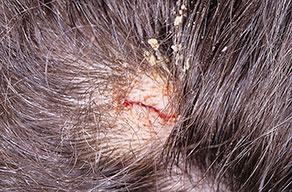


Caption: the photo shows a single, dome - shaped lump on the scalp, consistent with the location of a hair follicle, with a smooth surface, indicative of a diagnosis of a hair follicle cyst.
Nhãn thật: pilar cyst


,Hạng bệnh,Bệnh dự đoán,Xác suất,Hạng mệnh đề,Mệnh đề,Polarity,Support,Compatibility,Nguồn guideline
0,1,pilar cyst,0.7771,1,pain,Phủ định,0.0000,1.0000,"RAD guideline (Li et al., 2025), qwen_maxtoken..."
1,1,pilar cyst,0.7771,2,inflammation,Dương tính,0.9091,0.9091,"RAD guideline (Li et al., 2025), qwen_maxtoken..."
2,1,pilar cyst,0.7771,3,infection,Dương tính,0.9019,0.9019,"RAD guideline (Li et al., 2025), qwen_maxtoken..."
3,1,pilar cyst,0.7771,4,multiple lesions,Dương tính,0.8960,0.8960,"RAD guideline (Li et al., 2025), qwen_maxtoken..."
4,1,pilar cyst,0.7771,5,purulent drainage,Dương tính,0.8777,0.8777,"RAD guideline (Li et al., 2025), qwen_maxtoken..."
5,1,pilar cyst,0.7771,6,tenderness,Dương tính,0.8714,0.8714,"RAD guideline (Li et al., 2025), qwen_maxtoken..."
6,1,pilar cyst,0.7771,7,well-circumscribed round or oval skin-colored ...,Dương tính,0.8564,0.8564,"RAD guideline (Li et al., 2025), qwen_maxtoken..."
7,1,pilar cyst,0.7771,8,lesions on the scalp,Dương tính,0.8544,0.8544,"RAD guideline (Li et al., 2025), qwen_maxtoken..."
8,1,pilar cyst,0.7771,9,gradual enlargement over months to years,Dương tính,0.8543,0.8543,"RAD guideline (Li et al., 2025), qwen_maxtoken..."
9,1,pilar cyst,0.7771,10,rupture,Dương tính,0.8167,0.8167,"RAD guideline (Li et al., 2025), qwen_maxtoken..."


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from transformers import AutoTokenizer

# Dùng RUN_DIR đã chọn ở mục 3; không ghi đè bằng đường dẫn cố định.
CHECKLIST_DIR = RUN_DIR / "checklist"
EVIDENCE_PATH = CHECKLIST_DIR / "test_proposition_evidence.npz"
assert EVIDENCE_PATH.is_file(), f"Không tìm thấy evidence: {EVIDENCE_PATH}"

with np.load(EVIDENCE_PATH, allow_pickle=False) as evidence:
    AVAILABLE_SAMPLES = evidence["full_attention_sample_indices"].astype(int).tolist()

assert AVAILABLE_SAMPLES, "Artefact không có full attention để xem heatmap."
if "SAMPLE_INDEX" not in globals() or SAMPLE_INDEX not in AVAILABLE_SAMPLES:
    SAMPLE_INDEX = AVAILABLE_SAMPLES[0]

proposition_index = json.loads((CHECKLIST_DIR / "proposition_index.json").read_text(encoding="utf-8"))
disease_index = json.loads((CHECKLIST_DIR / "disease_index.json").read_text(encoding="utf-8"))
tokenizer = AutoTokenizer.from_pretrained(BERT_DIR, local_files_only=True, do_lower_case=True)

with np.load(EVIDENCE_PATH, allow_pickle=False) as evidence:
    image_path = str(evidence["image_paths"][SAMPLE_INDEX])
    target_index = int(np.argmax(evidence["gt"][SAMPLE_INDEX]))
    probabilities = evidence["pred_proposition"][SAMPLE_INDEX]
    compatibility = evidence["compatibility"][SAMPLE_INDEX]
    support = evidence["support"][SAMPLE_INDEX]
    caption_ids = evidence["caption_input_ids"][SAMPLE_INDEX]
    caption_mask = evidence["caption_attention_mask"][SAMPLE_INDEX].astype(bool)

caption = tokenizer.decode(caption_ids[caption_mask].tolist(), skip_special_tokens=True).strip()
top_disease_indices = np.argsort(-probabilities)[:3]

print("Ảnh:", image_path)
display(Image.open(image_path).convert("RGB"))
print("\nCaption:", caption or "(caption rỗng sau khi bỏ token đặc biệt)")
print("Nhãn thật:", disease_index[target_index]["disease_id"])

summary_rows = []
for rank, disease_position in enumerate(top_disease_indices, start=1):
    candidates = [
        proposition_position
        for proposition_position, proposition in enumerate(proposition_index)
        if proposition["disease_index"] == int(disease_position)
    ]
    strongest = sorted(candidates, key=lambda position: float(compatibility[position]), reverse=True)
    selected_propositions = strongest if rank == 1 else strongest[:3]

    for evidence_rank, proposition_position in enumerate(selected_propositions, start=1):
        proposition = proposition_index[proposition_position]
        summary_rows.append({
            "Hạng bệnh": rank,
            "Bệnh dự đoán": disease_index[int(disease_position)]["disease_id"],
            "Xác suất": float(probabilities[disease_position]),
            "Hạng mệnh đề": evidence_rank,
            "Mệnh đề": proposition["canonicalDescription"],
            "Polarity": "Dương tính" if proposition["polarity"] == 1 else "Phủ định",
            "Support": float(support[proposition_position]),
            "Compatibility": float(compatibility[proposition_position]),
            "Nguồn guideline": proposition["sourceReference"],
        })

display(pd.DataFrame(summary_rows).round({"Xác suất": 4, "Support": 4, "Compatibility": 4}))

### 11b. Tạo báo cáo attention đầy đủ mệnh đề cho riêng bệnh hạng 1

Đoạn code dưới đây sao chép lại cơ chế tạo file HTML từ mục 10, cấu hình đặc biệt chỉ lấy bệnh đứng đầu (hạng 1) và hiển thị toàn bộ các mệnh đề tương thích của nó.

In [ ]:
import subprocess
import sys
from IPython.display import IFrame, display

# Dùng biến do mục 9/11 đã tạo, không ghi đè RUN_DIR hay REPO_DIR.
RENDER_ROOT = CHECKLIST_DIR / "rendered_attention"
REPORT_RANK1_PATH = RENDER_ROOT / f"sample_{SAMPLE_INDEX:04d}" / "report_rank1_all_propositions.html"

disease_position_rank1 = int(top_disease_indices[0])
num_all_propositions = sum(
    proposition["disease_index"] == disease_position_rank1
    for proposition in proposition_index
)
assert num_all_propositions > 0, "Không có mệnh đề cho bệnh hạng 1."

command = [
    sys.executable,
    "proposition/visualization/render_attention.py",
    "--evidence", str(EVIDENCE_PATH),
    "--bert_model_name", str(BERT_DIR),
    "--output_dir", str(RENDER_ROOT),
    "--samples", str(SAMPLE_INDEX),
    "--diseases_per_sample", "1",
    "--propositions_per_disease", "0",  # 0 = toàn bộ mệnh đề của bệnh hạng 1
]

print(f"Tạo báo cáo đầy đủ cho {num_all_propositions} mệnh đề của bệnh hạng 1...")
subprocess.run(command, cwd=REPO_DIR, check=True)

default_report = RENDER_ROOT / f"sample_{SAMPLE_INDEX:04d}" / "report.html"
assert default_report.is_file(), f"Renderer không tạo report: {default_report}"
if REPORT_RANK1_PATH.is_file():
    REPORT_RANK1_PATH.unlink()
default_report.replace(REPORT_RANK1_PATH)

print("✅ Báo cáo đã sẵn sàng:", REPORT_RANK1_PATH)
display(IFrame(src=str(REPORT_RANK1_PATH), width="100%", height=1800))

Bệnh hạng 1 có tổng cộng 20 mệnh đề.
Đang sinh báo cáo đặc biệt...
✅ Báo cáo đặc biệt đã sẵn sàng: /content/drive/MyDrive/Cao học/Proposition-outputs/P1-20ep/20261006_184252/checklist/rendered_attention/sample_0030/report_rank1_all_propositions.html
